In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pickle
import sys
import seaborn as sns
from copy import deepcopy

from GroupMultiNeSS.MASE import MASE
from GroupMultiNeSS.data_generation import GroupLatentPositionGenerator
from GroupMultiNeSS.utils import mean_frobenius_error, frobenius_error, make_group_indices
from GroupMultiNeSS.group_multiness import GroupMultiNeSS, GroupMultiNeSSCV, OracleGroupMultiNeSS
from GroupMultiNeSS.multiness import MultiNeSS, MultiNeSSCV


sys.path.append(os.path.abspath(".."))
from utils.plot_utils import plot_components_errors

## Change n

In [3]:
random_state = 1
n_simultations = 5

In [4]:
n_range = [100, 200, 300, 400, 500]
M = 16
K = 4

s_vu=0.1
s_wu=0.1
s_vw = 0.

edge_distrib = "normal"
loops_allowed=True

d = 3
d_shared = d
d_groups=np.array([d] * K)
d_individs =np.array([d] * M)

group_props = np.ones(K) / K
group_indices = make_group_indices(group_props, M)

In [5]:
init_kwargs = {"max_rank": 3 * d, "loops_allowed": True, "n_jobs": K, "edge_distrib": edge_distrib}

fit_kwargs = {"lr": 1., "tol": 1e-5, "max_iter": 300, "refit": True, "verbose": False}

In [6]:
data_gen_kwargs = {"n_layers": M, "group_indices": group_indices,
                   "s_vu": s_vu, "s_wu": s_wu, "s_vw": s_vw, 
                   "edge_distrib": edge_distrib, "loops_allowed": True, "noise_sigma": 1,
                   "d_shared": d_shared, "d_individs": d_individs, "d_groups": d_groups}

In [6]:
n_2_errors_over_folds = {n: [] for n in n_range}

for fold in range(n_simultations):
    print(f"Started to work on fold={fold}!")
    for n in n_range:
        lpg = GroupLatentPositionGenerator(n_nodes=n, **data_gen_kwargs)
        lpg.generate(random_seed=fold)
        As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

        # gmn = GroupMultiNeSSCV(group_indices, **init_kwargs) 
        # Comment: CV res are identical to the theory-suggested rates, so we suggest no CV here
        
        gmn = GroupMultiNeSS(group_indices, **init_kwargs)
        gmn.fit(As, **fit_kwargs)
        error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                                   relative_errors=True)
        print(error_report)
        n_2_errors_over_folds[n].append(list(error_report.values()))

Started to work on fold=0!
{'Shared component': 0.04, 'Group components': 0.075, 'Individual components': 0.158, 'Ps': 0.101}
{'Shared component': 0.026, 'Group components': 0.05, 'Individual components': 0.108, 'Ps': 0.069}
{'Shared component': 0.021, 'Group components': 0.043, 'Individual components': 0.093, 'Ps': 0.059}
{'Shared component': 0.017, 'Group components': 0.036, 'Individual components': 0.08, 'Ps': 0.051}
{'Shared component': 0.016, 'Group components': 0.032, 'Individual components': 0.074, 'Ps': 0.047}
Started to work on fold=1!
{'Shared component': 0.041, 'Group components': 0.076, 'Individual components': 0.159, 'Ps': 0.101}
{'Shared component': 0.026, 'Group components': 0.051, 'Individual components': 0.109, 'Ps': 0.07}
{'Shared component': 0.021, 'Group components': 0.042, 'Individual components': 0.095, 'Ps': 0.06}
{'Shared component': 0.018, 'Group components': 0.035, 'Individual components': 0.082, 'Ps': 0.052}
{'Shared component': 0.016, 'Group components': 0.0

In [17]:
with open(f"saved_results/gmn_n_change_M_{M}_K_{K}_d_{d}.pkl", "wb") as f:
    pickle.dump(n_2_errors_over_folds, f)

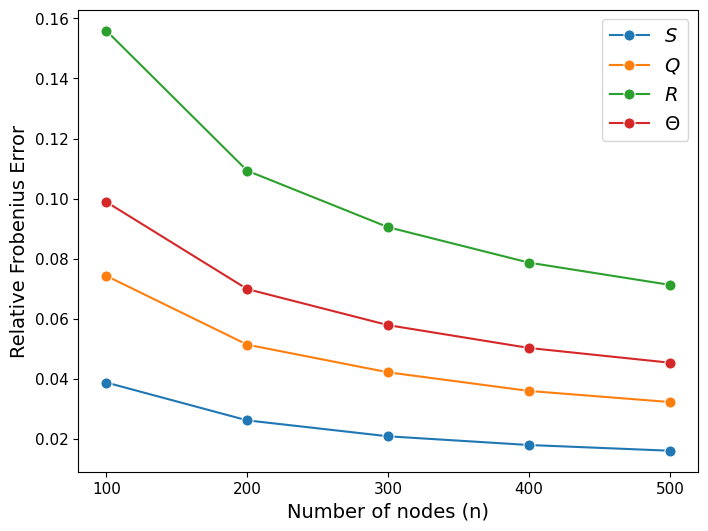

In [28]:
plot_components_errors(n_2_errors_over_folds, param_name="Number of nodes (n)", 
                       figsize=(8, 6), fontsize=14, plot_std=False, markersize=8)

In [6]:
with open(f"saved_results/gmn_n_change_M_{M}_K_{K}_d_{d}.pkl", "rb") as f:
    n_2_errors_over_folds = pickle.load(f)

## Change M

In [12]:
M_range = [8, 16, 24, 32, 40, 48]

n = 200

data_gen_kwargs = {"n_nodes": n, "s_vu": s_vu, "s_wu": s_wu, "s_vw": s_vw, 
                   "edge_distrib": edge_distrib, "loops_allowed": True, "noise_sigma": 1,
                   "d_shared": d_shared, "d_groups": d_groups}

In [115]:
m_2_errors_over_folds = {M: [] for M in M_range}

for fold in range(n_simultations):
    print(f"Started working with fold={fold}!")
    for M in M_range:

        group_props = np.ones(K) / K
        group_indices = make_group_indices(group_props, M)
        d_individs=np.array([d] * M)

        lpg = GroupLatentPositionGenerator(n_layers=M, group_indices=group_indices, d_individs=d_individs, **data_gen_kwargs)
        lpg.generate(random_seed=fold)
        As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

        # gmn = GroupMultiNeSSCV(group_indices, **init_kwargs) 
        # Comment: CV res are identical to the theory-suggested rates, so we suggest no CV here
        
        gmn = GroupMultiNeSS(group_indices=group_indices, **init_kwargs)
        gmn.fit(As, **fit_kwargs)
        error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                                   relative_errors=True)
        print(error_report)
        m_2_errors_over_folds[M].append(list(error_report.values()))

Started working with fold=0!
{'Shared component': 0.04, 'Group components': 0.081, 'Individual components': 0.126, 'Ps': 0.08}
{'Shared component': 0.026, 'Group components': 0.05, 'Individual components': 0.108, 'Ps': 0.069}
{'Shared component': 0.02, 'Group components': 0.041, 'Individual components': 0.108, 'Ps': 0.066}
{'Shared component': 0.018, 'Group components': 0.034, 'Individual components': 0.105, 'Ps': 0.063}
{'Shared component': 0.017, 'Group components': 0.03, 'Individual components': 0.106, 'Ps': 0.061}
Started working with fold=1!
{'Shared component': 0.039, 'Group components': 0.074, 'Individual components': 0.129, 'Ps': 0.084}
{'Shared component': 0.026, 'Group components': 0.051, 'Individual components': 0.109, 'Ps': 0.07}
{'Shared component': 0.021, 'Group components': 0.041, 'Individual components': 0.107, 'Ps': 0.066}
{'Shared component': 0.017, 'Group components': 0.034, 'Individual components': 0.107, 'Ps': 0.063}
{'Shared component': 0.016, 'Group components': 

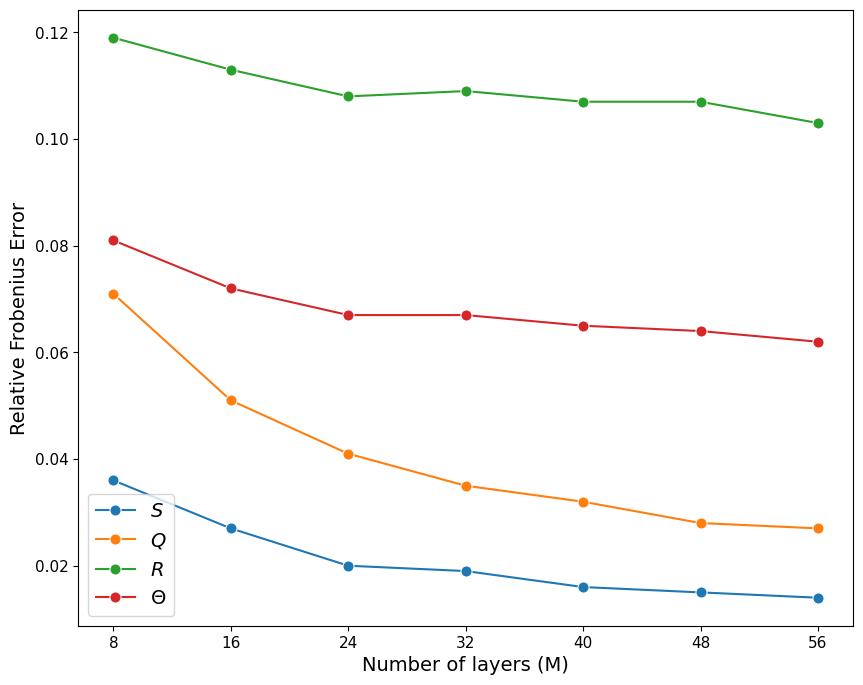

In [35]:
plot_components_errors(m_2_errors_over_folds, param_name="Number of layers (M)",
                      fontsize=14, plot_std=False, markersize=8)

In [ ]:
with open(f"saved_results/gmn_M_change_n_{n}_K_{K}_d_{d}.pkl", "wb") as f:
    pickle.dump(m_2_errors_over_folds, f)

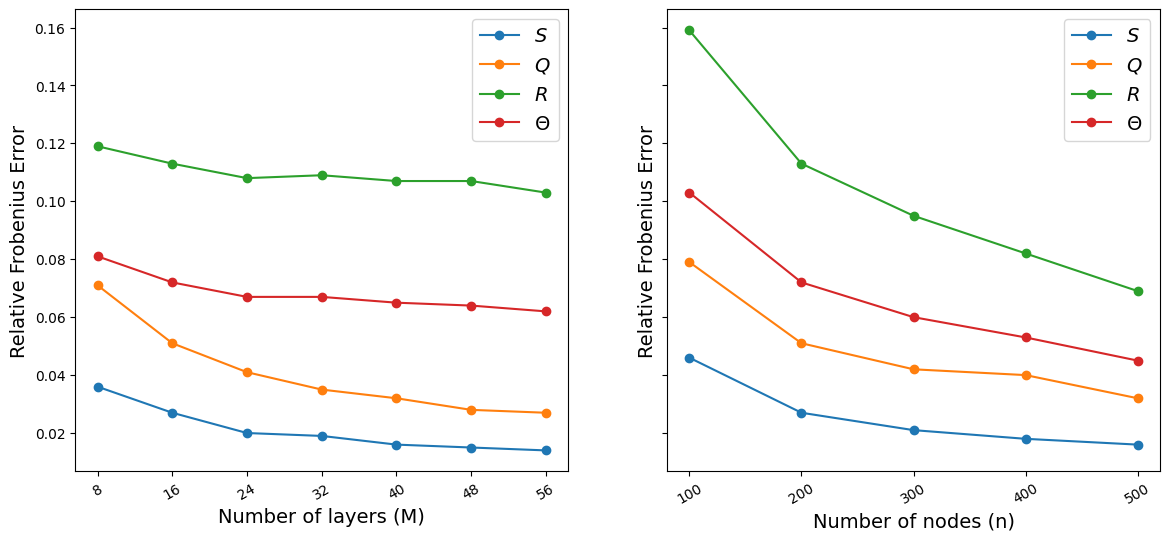

In [72]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(14, 6))

plot_components_errors(m_2_errors, param_name="Number of layers (M)", ax=axs[0], fontsize=14)
plot_components_errors(n_2_errors, param_name="Number of nodes (n)", ax=axs[1], fontsize=14)
plt.savefig("Figures/m_n_errors_gmn.pdf", dpi=200)

In [28]:
with open(f"saved_results/gmn_M_change_n_{n}_K_{K}_d_{d}.pkl", "rb") as f:
    m_2_errors_over_folds = pickle.load(f)

## Change $s_{uu}$

In [35]:
n = 200
M = 16
s_ww = 0.1

data_gen_kwargs = {"n_nodes": n, "n_layers": M, "group_indices": group_indices, 
                   "edge_distrib": edge_distrib, "loops_allowed": True, "noise_sigma": 1,
                   "d_shared": d_shared, "d_individs": d_individs, "d_groups": d_groups,
                   "s_wu": s_wu, "s_vu": s_vu, "s_vw": s_vw, "s_ww": s_ww}

In [36]:
s_uu_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
s_uu_range

[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

In [37]:
s_uu_2_errors = {}

In [38]:
# no iteration over random seeds as there is no variation

for s_uu in s_uu_range:
    print(f"Start working on s_uu={s_uu}!")
    lpg = GroupLatentPositionGenerator(s_uu=s_uu,  **data_gen_kwargs)
    lpg.generate(random_seed=random_state)
    As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs
    
    # gmn = GroupMultiNeSSCV(group_indices, **init_kwargs) 
    # Comment: CV res are identical to the theory-suggested rates, so we suggest no CV here
    gmn = GroupMultiNeSS(group_indices, **init_kwargs)
    gmn.fit(As, **fit_kwargs)
    error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                               relative_errors=True)
    print(error_report)
    s_uu_2_errors[s_uu] = list(error_report.values())

Start working on s_uu=0!
{'Shared component': 0.028, 'Group components': 0.051, 'Individual components': 0.11, 'Ps': 0.07}
Start working on s_uu=0.1!
{'Shared component': 0.028, 'Group components': 0.051, 'Individual components': 0.11, 'Ps': 0.071}
Start working on s_uu=0.2!
{'Shared component': 0.028, 'Group components': 0.051, 'Individual components': 0.109, 'Ps': 0.07}
Start working on s_uu=0.3!
{'Shared component': 0.029, 'Group components': 0.051, 'Individual components': 0.111, 'Ps': 0.071}
Start working on s_uu=0.4!
{'Shared component': 0.029, 'Group components': 0.051, 'Individual components': 0.116, 'Ps': 0.073}
Start working on s_uu=0.5!
{'Shared component': 0.048, 'Group components': 0.053, 'Individual components': 0.137, 'Ps': 0.082}
Start working on s_uu=0.6!
{'Shared component': 0.121, 'Group components': 0.053, 'Individual components': 0.181, 'Ps': 0.085}
Start working on s_uu=0.7!
{'Shared component': 0.211, 'Group components': 0.054, 'Individual components': 0.264, 'Ps


## Change $s_{ww}$

In [31]:
s_uu = 0.1

data_gen_kwargs = {"n_nodes": n, "n_layers": M, "group_indices": group_indices, 
                   "edge_distrib": edge_distrib, "loops_allowed": True, "noise_sigma": 1,
                   "d_shared": d_shared, "d_individs": d_individs, "d_groups": d_groups,
                   "s_wu": s_wu, "s_vu": s_vu, "s_vw": s_vw, "s_uu": s_uu}


In [32]:
s_ww_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [33]:
s_ww_2_errors = {}

In [34]:
# no iteration over random seeds as there is no variation

for s_ww in s_ww_range:
    print(f"Start working on s_ww={s_ww}!")
    lpg = GroupLatentPositionGenerator(s_ww=s_ww, **data_gen_kwargs)
    lpg.generate(random_seed=random_state)
    As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs
    
    # gmn = GroupMultiNeSSCV(group_indices, **init_kwargs) 
    # Comment: CV res are identical to the theory-suggested rates, so we suggest no CV here
    gmn = GroupMultiNeSS(group_indices, **init_kwargs)
    gmn.fit(As, **fit_kwargs)
    error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                               relative_errors=True)
    
    print(error_report)
    s_ww_2_errors[s_ww] = list(error_report.values())

Start working on s_ww=0!
{'Shared component': 0.028, 'Group components': 0.051, 'Individual components': 0.112, 'Ps': 0.071}
Start working on s_ww=0.1!
{'Shared component': 0.028, 'Group components': 0.051, 'Individual components': 0.11, 'Ps': 0.071}
Start working on s_ww=0.2!
{'Shared component': 0.029, 'Group components': 0.051, 'Individual components': 0.109, 'Ps': 0.07}
Start working on s_ww=0.3!
{'Shared component': 0.03, 'Group components': 0.05, 'Individual components': 0.108, 'Ps': 0.07}
Start working on s_ww=0.4!
{'Shared component': 0.043, 'Group components': 0.057, 'Individual components': 0.109, 'Ps': 0.071}
Start working on s_ww=0.5!
{'Shared component': 0.076, 'Group components': 0.086, 'Individual components': 0.109, 'Ps': 0.072}
Start working on s_ww=0.6!
{'Shared component': 0.136, 'Group components': 0.144, 'Individual components': 0.109, 'Ps': 0.076}
Start working on s_ww=0.7!
{'Shared component': 0.229, 'Group components': 0.235, 'Individual components': 0.109, 'Ps'

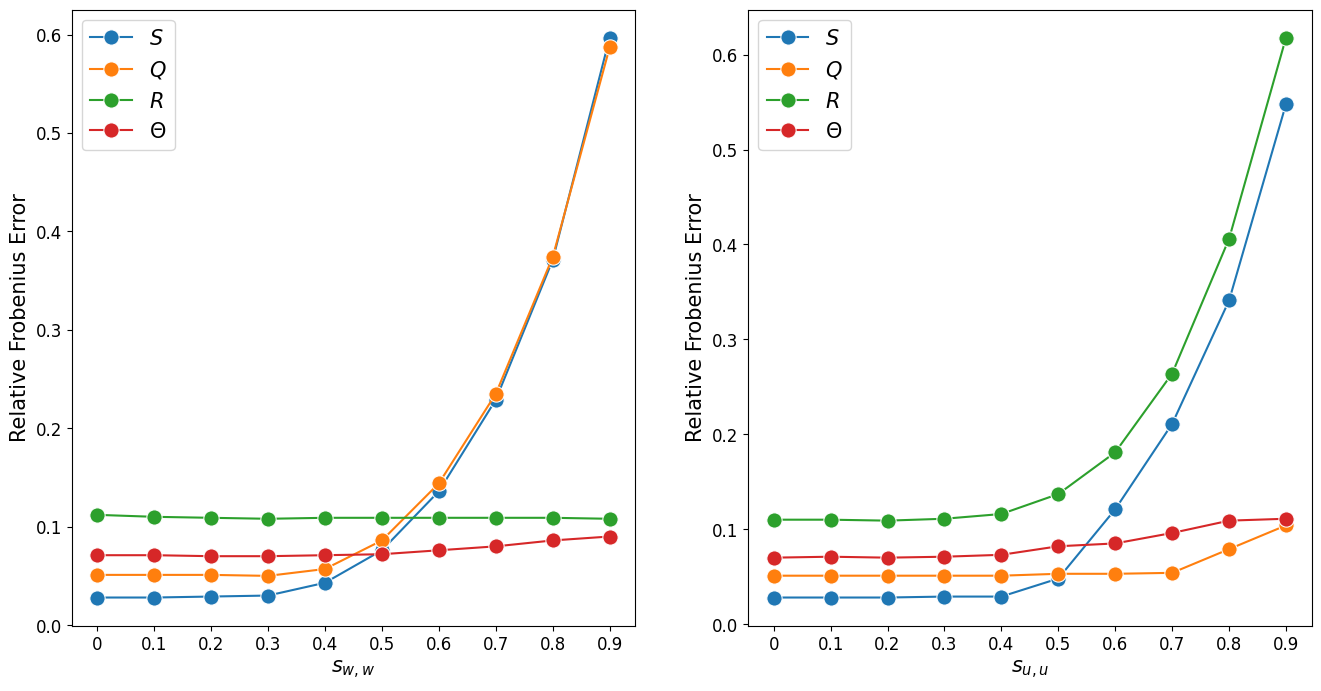

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs = axs.flatten()

for ax, name, err_dict in zip(axs, ["$s_{w,w}$", "$s_{u,u}$"], [s_ww_2_errors, s_uu_2_errors]):
    plot_components_errors(err_dict, param_name=name, ax=ax, 
                           fontsize=15, plot_std=False, markersize=11, plot_legend=True)

plt.savefig("Figures/s_uu_s_ww_dependency_gmn_gaus.pdf", dpi=200)

# Logistic Model

## Change n

In [8]:
M = 16
K = 4

s_vu=0.1
s_wu=0.1

edge_distrib = "bernoulli"
loops_allowed=True

d = 3
d_shared = d
d_groups = np.array([d] * K)
d_individs = np.array([d] * M)

group_props = np.ones(K) / K
group_indices = make_group_indices(group_props, M)

In [19]:
data_gen_kwargs = {"n_layers": M, "group_indices": group_indices, "s_vu": s_vu, "s_wu": s_wu, 
                   "edge_distrib": edge_distrib, "loops_allowed": True, "noise_sigma": 1.,
                   "d_shared": d_shared, "d_individs": d_individs, "d_groups": d_groups}

In [20]:
init_kwargs = {"max_rank": 2 * d, "loops_allowed": True, "n_jobs": K, "edge_distrib": edge_distrib}

fit_kwargs = {"lr": 3., "tol": 1e-5, "max_iter": 300, "verbose": False, "verbose_interval": 100}

In [10]:
n_range = [100, 200, 300, 400, 500]

n_2_errors_over_folds_logistic = {n: [] for n in n_range}
n_2_сv_results = {n: [] for n in n_range}

for fold in range(n_simulations):
    print(f"Started to work on fold={fold}!")
    for n in n_range:
        param_grid = {"lmbda2": K * np.sqrt(n / M) * np.array([0.1, 0.3, 1., 3, 5, 10]),
                      "lmbda1": np.sqrt(n * M / K) * np.array([0.1, 0.3, 1., 3, 5])}
        # print(f"Started working with n={n}!")
        lpg = GroupLatentPositionGenerator(n_nodes=n, **data_gen_kwargs)
        lpg.generate(random_seed=fold)
        As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

        gmn = GroupMultiNeSSCV(group_indices, param_grid=param_grid, cv_folds=3, **init_kwargs)
        # gmn = GroupMultiNeSS(group_indices, **init_kwargs)
        gmn.fit(As, refit=True, **fit_kwargs)
        error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                                   relative_errors=True)
        print(error_report)
        best_params = gmn.get_best_params_dict()
        n_2_errors_over_folds_logistic[n].append(list(error_report.values()))
        n_2_сv_results[n].append(gmn.get_cv_results())
        
with open(f"saved_results/gmn_logistic_n_change_M_{M}_K_{K}_d_{d}.pkl", "wb") as f:
    pickle.dump(n_2_errors_over_folds_logistic, f)

In [12]:
with open(f"saved_results/gmn_logistic_n_change_M_{M}_K_{K}_d_{d}.pkl", "rb") as f:
    n_2_errors_over_folds_logistic = pickle.load(f)

## Change M

In [16]:
M_range = [8, 16, 24, 32, 40, 48]

n = 200
K = 4

s_vu=0.1
s_wu=0.1

edge_distrib = "bernoulli"
loops_allowed=True

d = 3
d_shared = d
d_groups = np.array([d] * K)

data_gen_kwargs = {"n_nodes": n, "s_vu": s_vu, "s_wu": s_wu, 
                   "edge_distrib": edge_distrib, "loops_allowed": True,
                   "d_shared": d_shared, "d_groups": d_groups}

In [27]:
init_kwargs = {"max_rank": 2 * d, "loops_allowed": True, "n_jobs": K, "edge_distrib": edge_distrib}

fit_kwargs = {"lr": 3., "tol": 1e-5, "max_iter": 300, "verbose": False, "verbose_interval": 100}

In [9]:
m_2_errors_over_folds_logistic = {M: [] for M in M_range}

for fold in range(n_simultations):
    print(f"Started working with fold={fold}!")
    for M in M_range:

        group_props = np.ones(K) / K
        group_indices = make_group_indices(group_props, M)
        d_individs=np.array([d] * M)
        
        param_grid = {"lmbda2": K * np.sqrt(n / M) * np.array([0.1, 0.3, 1., 3, 5, 10]),
                      "lmbda1": np.sqrt(n * M / K) * np.array([0.1, 0.3, 1., 3, 5])}
        
        lpg = GroupLatentPositionGenerator(n_layers=M, group_indices=group_indices, d_individs=d_individs, 
                                           **data_gen_kwargs)
        lpg.generate(random_seed=fold)
        As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

        # gmn = GroupMultiNeSS(group_indices=group_indices, **init_kwargs)
        gmn = GroupMultiNeSSCV(group_indices=group_indices, param_grid=param_grid, **init_kwargs)
        gmn.fit(As, refit=True, **fit_kwargs)
        error_report = gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps, 
                                                   relative_errors=True)
        print(error_report)
        m_2_errors_over_folds_logistic[M].append(list(error_report.values()))
        
with open(f"saved_results/gmn_logistic_m_change_n_{n}_K_{K}_d_{d}.pkl", "wb") as f:
    pickle.dump(m_2_errors_over_folds_logistic, f)

In [29]:
with open(f"saved_results/gmn_logistic_m_change_M_{M}_K_{K}_d_{d}.pkl", "rb") as f:
    m_2_errors_over_folds_logistic = pickle.load(f)

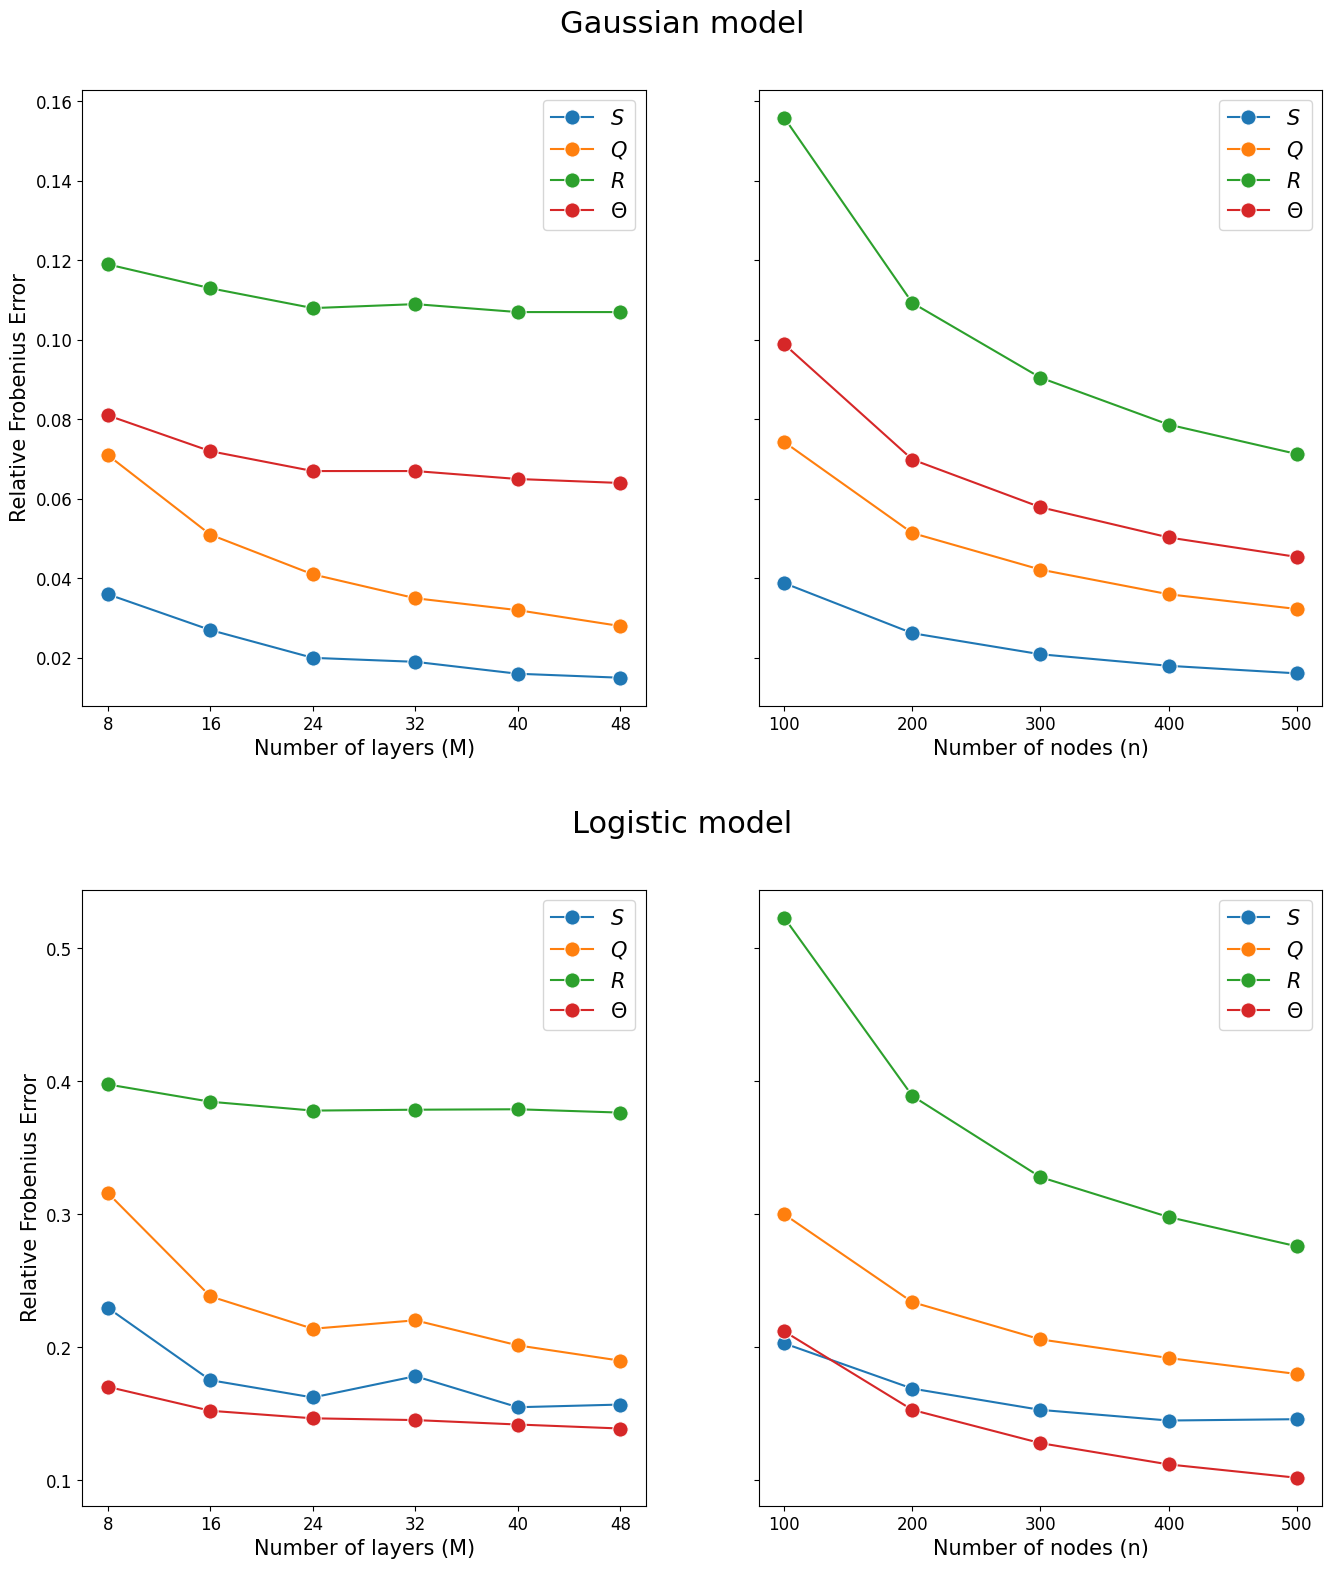

In [49]:
fig = plt.figure(figsize=(16, 16))


subfigs = fig.subfigures(nrows=2, ncols=1)
axs = subfigs[0].subplots(nrows=1, ncols=2, sharey=True)
subfigs[0].suptitle('Gaussian model', fontsize=22)
plot_components_errors(m_2_errors_over_folds, param_name="Number of layers (M)", ax=axs[0], 
                       fontsize=15, plot_std=False, markersize=11,)
plot_components_errors(n_2_errors_over_folds, param_name="Number of nodes (n)", ax=axs[1],
                      fontsize=15, plot_std=False, markersize=11)


axs = subfigs[1].subplots(nrows=1, ncols=2, sharey=True)
subfigs[1].suptitle('Logistic model', fontsize=22)
plot_components_errors(m_2_errors_over_folds_logistic, param_name="Number of layers (M)", ax=axs[0], 
                       fontsize=15, plot_std=False, markersize=11,)
plot_components_errors(n_2_errors_over_folds_logistic, param_name="Number of nodes (n)", ax=axs[1],
                      fontsize=15, plot_std=False, markersize=11)
plt.savefig("Figures/key_parameter_error_dependency_gmn_gaus_and_logistic.pdf", dpi=200)